<a href="https://colab.research.google.com/github/ShashankBDSC/Customer-segmentation/blob/main/playstoreEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Playstore data analysis**

**Project Type - Exploratory Data Analysis (EDA)**

**Contribution - Individual**

**Team Member 1 - SHASHANK BAJPAI**

#**Github Link ::**

https://github.com/ShashankBDSC

# ***Let's Begin !***

## ***1. Knowing The Data***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/content/Play Store Data.csv')
df.shape

(10841, 13)

## ***2. Understanding The Variables***

In [3]:
list(df.columns)

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

1. **App** : Name of the app
2. **Category** : The category to  which the app belongs
3. **Rating** : Rating received by an app out of 5
4. **Reviews** : No. Of reviews received by app
5. **Size** : The of size app in Megabytes(M) and Kilobytes(k)
6.**Installs** : No of installs the app has received
7.**Type** : Whether the app is free or paid
8.**Content Rating** : Content served by the app
9.   **Genres** : Genre of the app         
10. **Last Updated** : date when the app was last updated    
11.  **Current Ver** : Current Version of the app
12.  **Android Ver** : Android Version supported by the app

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


## 3. ***Data Wrangling*** ***and Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

####Checking for dupicate rows and removing them

In [5]:
df.duplicated().sum()

483

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

0

####Dealing with NaN values:

In [8]:
df.isnull().sum()


,0
App,0
Category,0
Rating,1465
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [9]:
df['Rating'].isnull().sum()/df.shape[0]*100

14.143657076655725

***Here we can see 14% data is missing from Rating column***

In [10]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


#####Checking for **unique values** in each column:

In [11]:
for i in df:
  print(i)
  print(df[i].unique(),df[i].nunique())

App
['Photo Editor & Candy Camera & Grid & ScrapBook' 'Coloring book moana'
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps' ...
 'Parkinson Exercices FR' 'The SCP Foundation DB fr nn5n'
 'iHoroscope - 2018 Daily Horoscope & Astrology'] 9660
Category
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9'] 34
Rating
[ 4.1  3.9  4.7  4.5  4.3  4.4  3.8  4.2  4.6  3.2  4.   nan  4.8  4.9
  3.6  3.7  3.3  3.4  3.5  3.1  5.   2.6  3.   1.9  2.5  2.8  2.7  1.
  2.9  2.3  2.2  1.7  2.   1.8  2.4  1.6  2.1  1.4  1.5  1.2 19. ] 40
Reviews
['159' '967' '87510' ... '603' '1195' '3983

So we can seee that **Rating column** has some **wrong entries** as values are **greater than 5**

In [12]:
df[df['Rating']>5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,11-Feb-18,1.0.19,4.0 and up,NaN


In [13]:
df.drop(10472,inplace=True)

#####Converting the data type of various columns for further analysis

In [14]:
df.Installs=df.Installs.str.replace('+','')
df.Installs=df.Installs.str.replace(',','')

In [15]:
df['Installs'].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [16]:
df[['Reviews','Installs']]=df[['Reviews','Installs']].astype(int)

In [17]:
df.Price=df.Price.str.replace('$','')

In [18]:
df.Type=df.Type.str.replace('0','Free')

In [19]:
df['Price'].unique()

array(['0', '4.99 ', '3.99 ', '6.99 ', '1.49 ', '2.99 ', '7.99 ', '5.99 ',
       '3.49 ', '1.99 ', '9.99 ', '7.49 ', '0.99 ', '9.00 ', '5.49 ',
       '10.00 ', '24.99 ', '11.99 ', '79.99 ', '16.99 ', '14.99 ',
       '1.00 ', '29.99 ', '12.99 ', '2.49 ', '10.99 ', '1.50 ', '19.99 ',
       '15.99 ', '33.99 ', '74.99 ', '39.99 ', '3.95 ', '4.49 ', '1.70 ',
       '8.99 ', '2.00 ', '3.88 ', '25.99 ', '399.99 ', '17.99 ',
       '400.00 ', '3.02 ', '1.76 ', '4.84 ', '4.77 ', '1.61 ', '2.50 ',
       '1.59 ', '6.49 ', '1.29 ', '5.00 ', '13.99 ', '299.99 ', '379.99 ',
       '37.99 ', '18.99 ', '389.99 ', '19.90 ', '8.49 ', '1.75 ',
       '14.00 ', '4.85 ', '46.99 ', '109.99 ', '154.99 ', '3.08 ',
       '2.59 ', '4.80 ', '1.96 ', '19.40 ', '3.90 ', '4.59 ', '15.46 ',
       '3.04 ', '4.29 ', '2.60 ', '3.28 ', '4.60 ', '28.99 ', '2.95 ',
       '2.90 ', '1.97 ', '200.00 ', '89.99 ', '2.56 ', '30.99 ', '3.61 ',
       '394.99 ', '1.26 ', '1.20 ', '1.04 '], dtype=object)

In [20]:
df[df['Rating'].isnull()].sort_values(by='Reviews',ascending=False).head(20)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3589,We learn children's verses in kindergarten,PARENTING,NaN,3248,6.5M,100000,Free,0,Everyone,Parenting;Education,20-Dec-17,2.1,4.0 and up
9567,Adivina el Emoji,GAME,NaN,2536,32M,100000,Free,0,Everyone,Trivia,2-Oct-16,1,4.0.3 and up
1559,Young Speeches,LIBRARIES_AND_DEMO,NaN,2221,2.4M,500000,Free,0,Everyone,Libraries & Demo,8-Jan-17,1.1,2.3 and up
321,【Ranobbe complete free】 Novelba - Free app tha...,COMICS,NaN,1330,22M,50000,Free,0,Everyone,Comics,3-Jul-18,6.1.1,4.2 and up
9612,Em Fuga Brasil,FAMILY,NaN,1317,60M,100000,Free,0,Everyone,Simulation,22-Apr-18,1,4.1 and up
3621,Voice Tables - no internet,PARENTING,NaN,970,71M,100000,Free,0,Everyone,Parenting,28-May-18,2,4.0.3 and up
704,Ai La Trieu Phu - ALTP Free,EDUCATION,NaN,776,24M,100000,Free,0,Everyone,Education,23-Jul-18,1.5,4.0 and up
126,Skin Care and Natural Beauty,BEAUTY,NaN,654,7.4M,100000,Free,0,Teen,Beauty,17-Jul-18,1.15,4.1 and up
5840,Holy Quran Mehmet Emin Ay,LIFESTYLE,NaN,649,55M,10000,Free,0,Everyone,Lifestyle,14-Mar-17,1.3.1,4.0.3 and up
1520,Luffs,LIBRARIES_AND_DEMO,NaN,487,3.7M,100000,Free,0,Everyone,Libraries & Demo,16-Jan-18,1,4.0.3 and up


In [21]:
df[df['Rating'].isnull()]['Installs'].value_counts()

,count
Installs,
100,407
10,316
1000,192
50,148
500,129
5,73
1,64
10000,44
5000,43


In [22]:
 df.dropna(inplace=True,ignore_index=True)

In [23]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [24]:
df[['Price','Rating']]=df[['Price','Rating']].astype('float')

In [25]:
df['Last Updated']=pd.to_datetime(df['Last Updated'],format='%d-%b-%y')

In [26]:
df.rename(columns={'Installs':'Installs_In_Million','Content Rating':'Content_Rating','Last Updated':'Last_Updated','Current Ver':'Current_Ver','Android Ver':'Android_Ver'},inplace=True)

In [27]:
i=df['App'].value_counts().reset_index()
i

,App,count
0,ROBLOX,9
1,8 Ball Pool,7
2,Bubble Shooter,6
3,Helix Jump,6
4,Zombie Catchers,6
...,...,...
8185,Block City Wars + skins export,1
8186,KineMaster – Pro Video Editor,1
8187,Koi Live Wallpaper,1
8188,Geometry Dash Meltdown,1


In [28]:
i[i['count']>1]

,App,count
0,ROBLOX,9
1,8 Ball Pool,7
2,Bubble Shooter,6
3,Helix Jump,6
4,Zombie Catchers,6
...,...,...
516,Final Fantasy XV: A New Empire,2
517,"Phogy, 3D Camera",2
518,Puffin Web Browser,2
519,Candy Crush Jelly Saga,2


So we can see here that the correct data should have only **8190 rows** but beacuse of errors during data entry the rows have increased to **8886**

In [29]:
app1=df[df['App']=='ROBLOX'].sort_values(by='Reviews',ascending=[False])
app1

,App,Category,Rating,Reviews,Size,Installs_In_Million,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver
1873,ROBLOX,FAMILY,4.5,4450890,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up
1775,ROBLOX,FAMILY,4.5,4450855,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up
1571,ROBLOX,GAME,4.5,4449910,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up
1704,ROBLOX,FAMILY,4.5,4449910,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up
1543,ROBLOX,GAME,4.5,4449882,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up
1456,ROBLOX,GAME,4.5,4448791,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up
1364,ROBLOX,GAME,4.5,4447388,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up
1412,ROBLOX,GAME,4.5,4447346,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up
3891,ROBLOX,FAMILY,4.5,4443407,67M,100000000,Free,0.0,Everyone 10+,Adventure;Action & Adventure,2018-07-31,2.347.225742,4.1 and up


In [30]:
app2=df[df['App']=='8 Ball Pool'].sort_values(by='Reviews',ascending=False)
app2

,App,Category,Rating,Reviews,Size,Installs_In_Million,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver
1572,8 Ball Pool,GAME,4.5,14201891,52M,100000000,Free,0.0,Everyone,Sports,2018-07-31,4.0.0,4.0.3 and up
1662,8 Ball Pool,GAME,4.5,14201604,52M,100000000,Free,0.0,Everyone,Sports,2018-07-31,4.0.0,4.0.3 and up
1546,8 Ball Pool,GAME,4.5,14200550,52M,100000000,Free,0.0,Everyone,Sports,2018-07-31,4.0.0,4.0.3 and up
1462,8 Ball Pool,GAME,4.5,14200344,52M,100000000,Free,0.0,Everyone,Sports,2018-07-31,4.0.0,4.0.3 and up
1414,8 Ball Pool,GAME,4.5,14198602,52M,100000000,Free,0.0,Everyone,Sports,2018-07-31,4.0.0,4.0.3 and up
1386,8 Ball Pool,GAME,4.5,14198297,52M,100000000,Free,0.0,Everyone,Sports,2018-07-31,4.0.0,4.0.3 and up
3361,8 Ball Pool,SPORTS,4.5,14184910,52M,100000000,Free,0.0,Everyone,Sports,2018-07-31,4.0.0,4.0.3 and up


In [31]:
df[df['App']=='Moneycontrol – Stocks, Sensex, Mutual Funds, IPO']

,App,Category,Rating,Reviews,Size,Installs_In_Million,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver
932,"Moneycontrol – Stocks, Sensex, Mutual Funds, IPO",FINANCE,4.4,281485,Varies with device,5000000,Free,0.0,Everyone,Finance,2018-05-11,Varies with device,Varies with device
8148,"Moneycontrol – Stocks, Sensex, Mutual Funds, IPO",FINANCE,4.4,281635,Varies with device,5000000,Free,0.0,Everyone,Finance,2018-08-06,Varies with device,Varies with device


In [32]:
df[df['App']=='Video Editor']

,App,Category,Rating,Reviews,Size,Installs_In_Million,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver
1897,Video Editor,FAMILY,4.1,159619,23M,5000000,Free,0.0,Everyone,Video Players & Editors;Creativity,2018-07-17,6.14.091,4.3 and up
3139,Video Editor,VIDEO_PLAYERS,4.1,159622,23M,5000000,Free,0.0,Everyone,Video Players & Editors;Creativity,2018-07-17,6.14.091,4.3 and up
4976,Video Editor,VIDEO_PLAYERS,3.8,1156,23M,100000,Free,0.0,Everyone,Video Players & Editors,2015-10-20,1.3.9b,4.3 and up


Here we can see that in our data there are **some apps** whose data is present more than once just because of the change in **reviews** and also because of presence of an app in more than **1 category.**

In [33]:
list(df[df['App']=='Solitaire'].sort_values(by='Reviews',ascending=False).iloc[1:,:].index)

[1665, 1712]

In [34]:
la=list(i['App'])

In [35]:
len(la)

8190

In [36]:
t=[]
for  i in la:
  t.extend(list(df[df['App']==i].sort_values(by='Reviews',ascending=False).iloc[1:,:].index))

In [37]:
df3=df.drop(index=t)

In [38]:
df3

,App,Category,Rating,Reviews,Size,Installs_In_Million,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,50000,Free,0.0,Everyone,Art & Design,2017-03-26,1,2.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8881,FR Calculator,FAMILY,4.0,7,2.6M,500,Free,0.0,Everyone,Education,2017-06-18,1.0.0,4.1 and up
8882,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up
8883,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100,Free,0.0,Everyone,Education,2018-07-06,1,4.1 and up
8884,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device


In [39]:
df3['App'].value_counts()

,count
App,
Photo Editor & Candy Camera & Grid & ScrapBook,1
usgang.ch,1
C I Patel School,1
CI Dictionary,1
Thistletown CI,1
...,...
News Republic,1
HuffPost - News,1
AP Mobile - Breaking News,1


In [40]:
df=df3.copy()

In [41]:
df['Installs_In_Million']/=1000000

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8190 entries, 0 to 8885
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   App                  8190 non-null   object        
 1   Category             8190 non-null   object        
 2   Rating               8190 non-null   float64       
 3   Reviews              8190 non-null   int64         
 4   Size                 8190 non-null   object        
 5   Installs_In_Million  8190 non-null   float64       
 6   Type                 8190 non-null   object        
 7   Price                8190 non-null   float64       
 8   Content_Rating       8190 non-null   object        
 9   Genres               8190 non-null   object        
 10  Last_Updated         8190 non-null   datetime64[ns]
 11  Current_Ver          8190 non-null   object        
 12  Android_Ver          8190 non-null   object        
dtypes: datetime64[ns](1), float64(3), int6

In [43]:
df.head()

,App,Category,Rating,Reviews,Size,Installs_In_Million,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,0.01,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5.00,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50.00,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,0.10,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,0.05,Free,0.0,Everyone,Art & Design,2017-03-26,1,2.3 and up


In [44]:
df.describe(exclude=['datetime','object'])

,Rating,Reviews,Installs_In_Million,Price
count,8190.000000,8.190000e+03,8190.000000,8190.000000
mean,4.173346,2.556849e+05,9.195983,1.035902
std,0.536319,1.986425e+06,58.283576,16.863402
min,1.000000,1.000000e+00,0.000001,0.000000
25%,4.000000,1.270000e+02,0.010000,0.000000
50%,4.300000,3.020000e+03,0.100000,0.000000
75%,4.500000,4.405325e+04,1.000000,0.000000
max,5.000000,7.815831e+07,1000.000000,400.000000


###Exploratory Data Analysis (EDA):

###Univariate Analysis:

In [45]:
numerical_df=df.select_dtypes(exclude=['object','datetime'])

In [46]:
numerical_df

,Rating,Reviews,Installs_In_Million,Price
0,4.1,159,0.0100,0.0
2,4.7,87510,5.0000,0.0
3,4.5,215644,50.0000,0.0
4,4.3,967,0.1000,0.0
5,4.4,167,0.0500,0.0
...,...,...,...,...
8881,4.0,7,0.0005,0.0
8882,4.5,38,0.0050,0.0
8883,5.0,4,0.0001,0.0
8884,4.5,114,0.0010,0.0


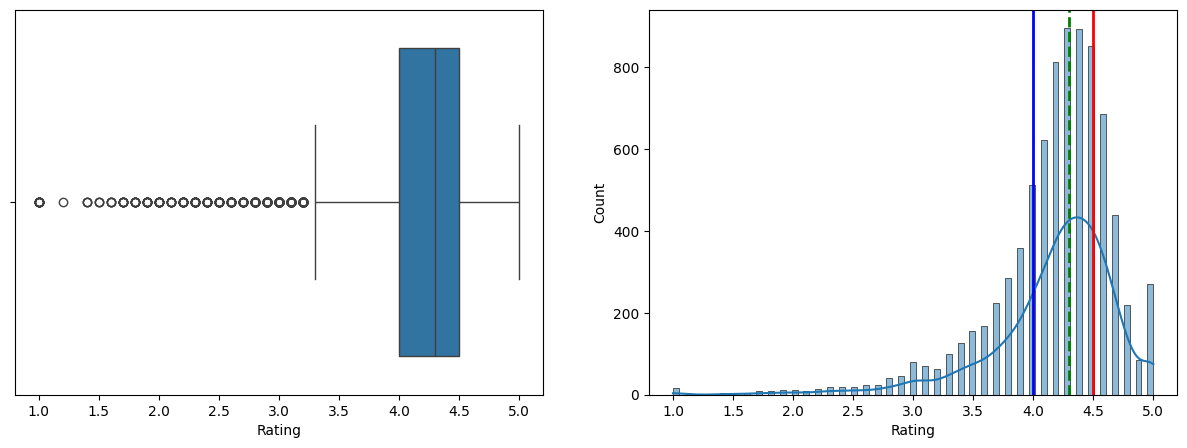

In [47]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
quartiles = np.percentile(df['Rating'], [25, 50, 75])
sns.boxplot(numerical_df,x='Rating')


plt.subplot(1,2,2)
sns.histplot(numerical_df,x='Rating',kde=True)
plt.axvline(quartiles[0], color='blue', linestyle='-', linewidth=2, label='25th percentile')
plt.axvline(quartiles[1], color='green', linestyle='--', linewidth=2, label='50th percentile (median)')
plt.axvline(quartiles[2], color='red', linestyle='-', linewidth=2, label='75th percentile')
plt.show()

from the above graph we can visualise that 50 % of the have ratings between **4 and 4.5** and few apps have received ratings **less than 3**

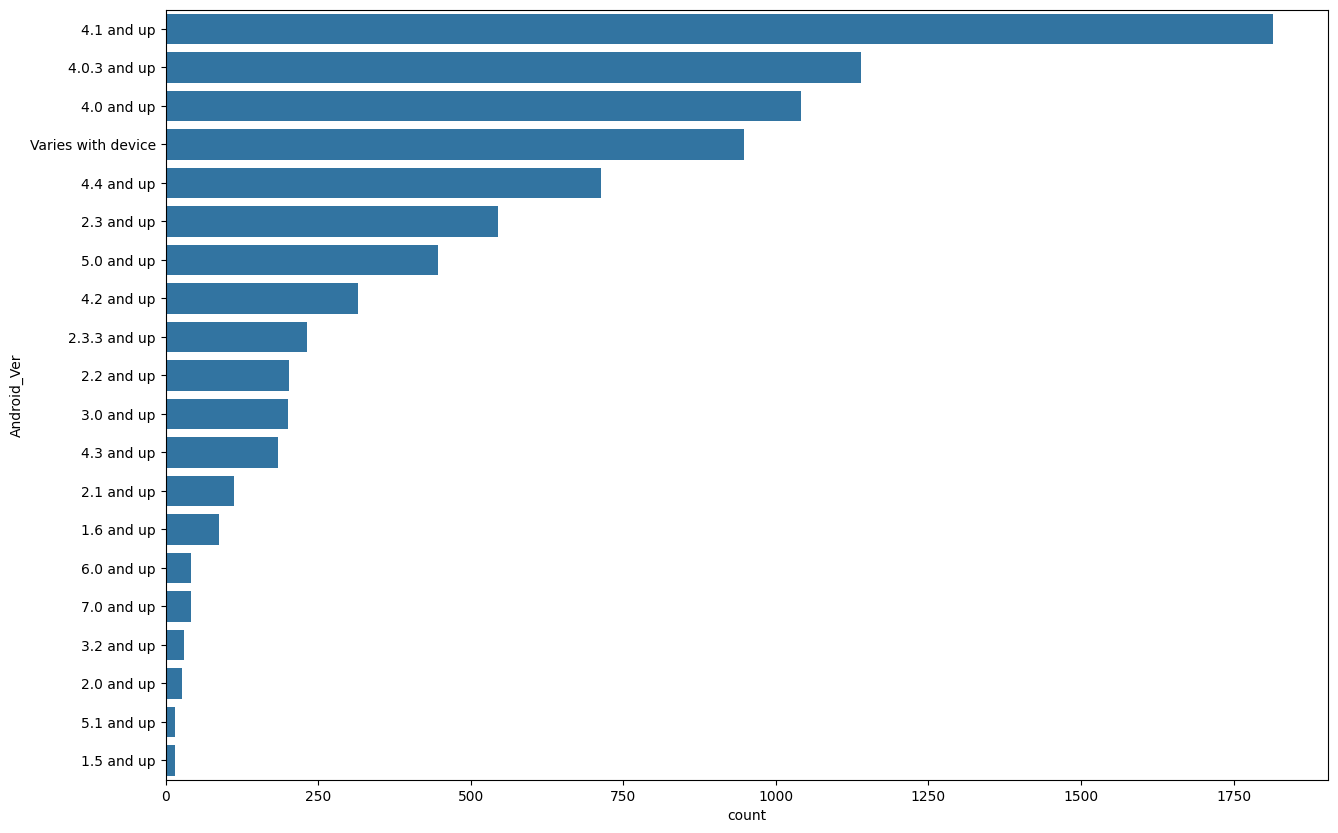

In [48]:
plt.figure(figsize=(15,10))
t=df['Android_Ver'].value_counts().reset_index().head(20)
sns.barplot(data=t,y='Android_Ver',x='count')
plt.show()

Here we can see that android version most supported by apps are **4.1 , 4.0.3 , 4.0 are 4.4**

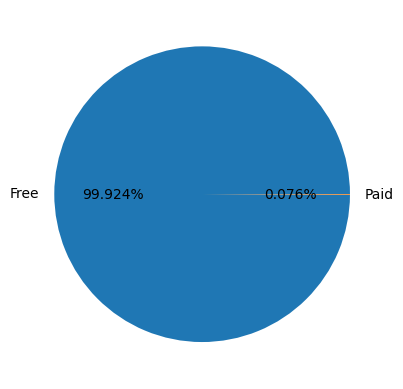

In [49]:
cat3df=df.groupby('Type')[['Installs_In_Million']].sum().sort_values(by=['Installs_In_Million'],ascending=False).reset_index().head(10)
plt.pie(x=cat3df['Installs_In_Million'],labels=cat3df['Type'],autopct='%1.03f%%')
plt.show()

The pie chart depicts that mostly all of the apps are free

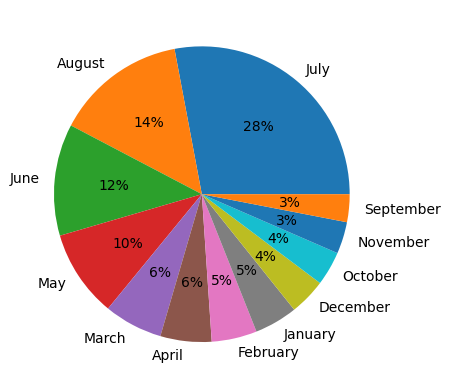

In [50]:
df['Updated_year']=df['Last_Updated'].dt.year
df['Updated_month']=df['Last_Updated'].dt.month_name()
d=df['Updated_month'].value_counts().reset_index()
plt.pie(x=d['count'],labels=d['Updated_month'],autopct='%1.0f%%')
plt.show()

The pie chart states that most of the apps are updated in **July** followed by **August** and **June**

In [51]:
df.sort_values(by='Price',ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs_In_Million,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver,Updated_year,Updated_month
3747,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3M,0.010,Paid,400.00,Everyone,Lifestyle,2018-05-03,1.0.1,4.1 and up,2018,May
4616,I AM RICH PRO PLUS,FINANCE,4.0,36,41M,0.001,Paid,399.99,Everyone,Finance,2018-06-25,1.0.2,4.1 and up,2018,June
4601,I am Rich!,FINANCE,3.8,93,22M,0.001,Paid,399.99,Everyone,Finance,2017-12-11,1,4.1 and up,2017,December
4605,I Am Rich Pro,FAMILY,4.4,201,2.7M,0.005,Paid,399.99,Everyone,Entertainment,2017-05-30,1.54,1.6 and up,2017,May
3742,💎 I'm rich,LIFESTYLE,3.8,718,26M,0.010,Paid,399.99,Everyone,Lifestyle,2018-03-11,1.0.0,4.4 and up,2018,March
4594,I am rich,LIFESTYLE,3.8,3547,1.8M,0.100,Paid,399.99,Everyone,Lifestyle,2018-01-12,2,4.0.3 and up,2018,January
4602,I am rich(premium),FINANCE,3.5,472,965k,0.005,Paid,399.99,Everyone,Finance,2017-05-01,3.4,4.4 and up,2017,May
4597,I am Rich Plus,FAMILY,4.0,856,8.7M,0.010,Paid,399.99,Everyone,Entertainment,2018-05-19,3,4.4 and up,2018,May
4612,I am Rich,FINANCE,4.3,180,3.8M,0.005,Paid,399.99,Everyone,Finance,2018-03-22,1,4.2 and up,2018,March
4607,I am rich (Most expensive app),FINANCE,4.1,129,2.7M,0.001,Paid,399.99,Teen,Finance,2017-12-06,2,4.0.3 and up,2017,December


###**Bivariate Analysis:**

####Which **App** , **Category** , **Content_Rating** , **Genres** And **Type** has the most  **Installs**?

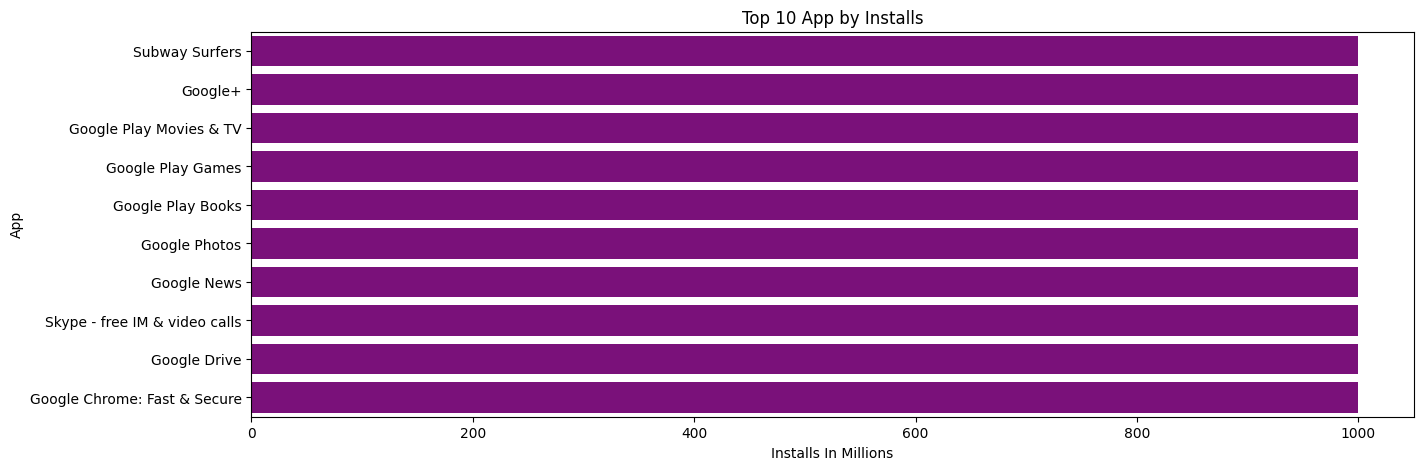

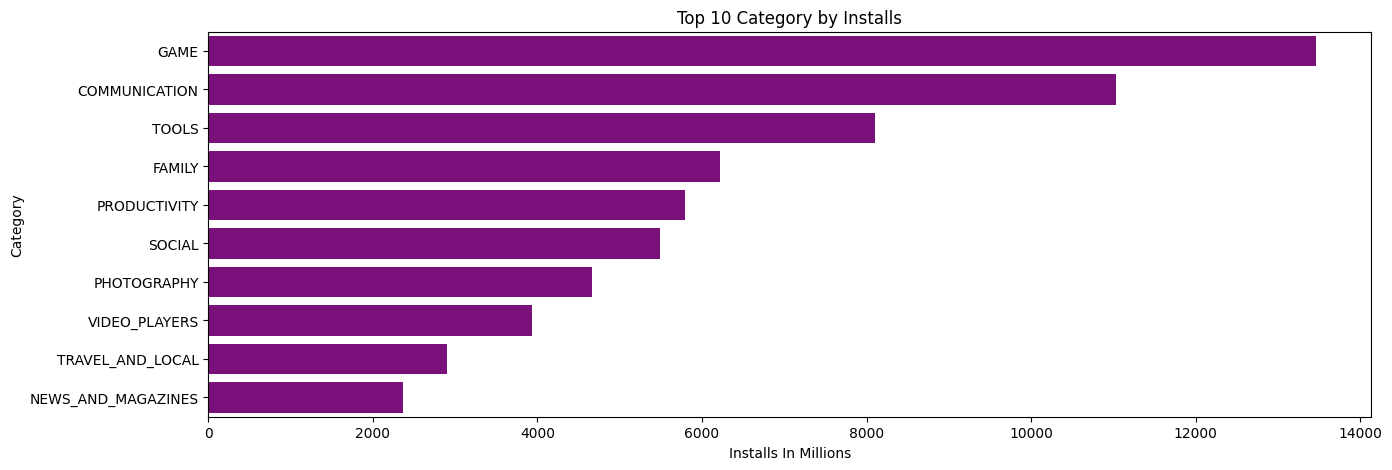

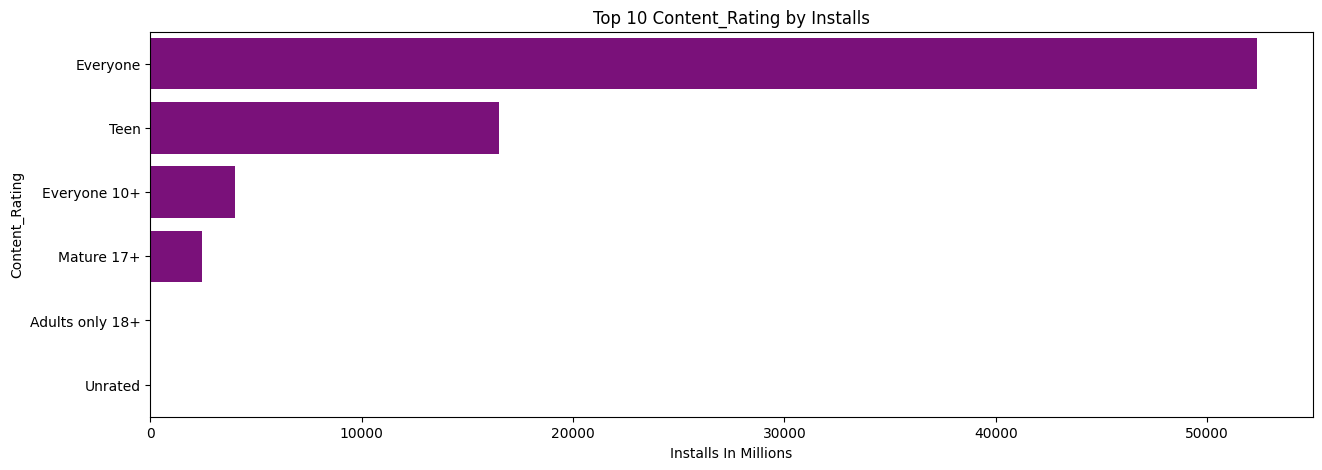

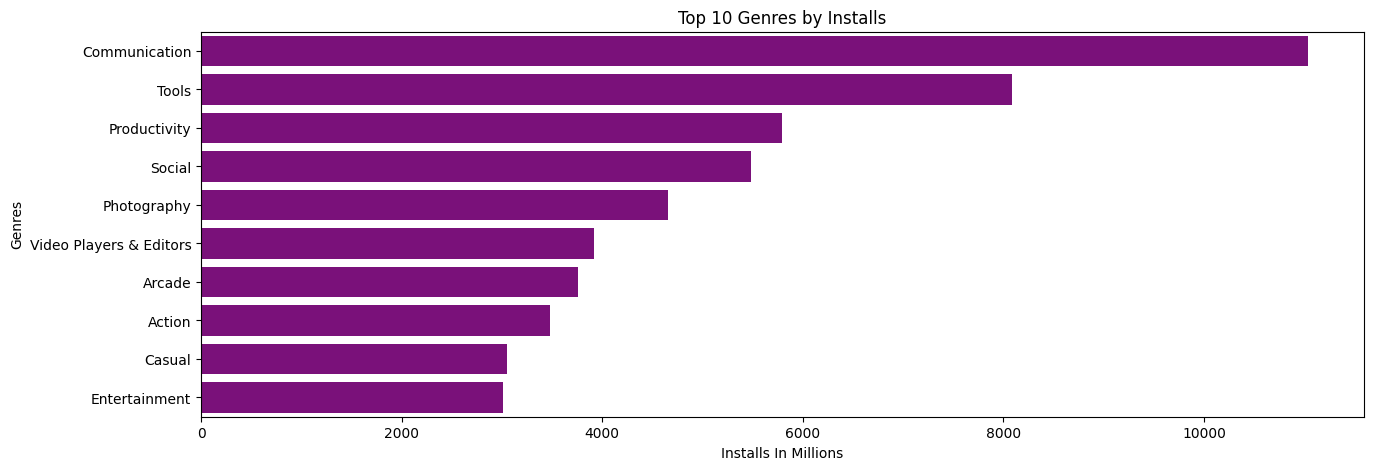

In [52]:
for i in ['App','Category','Content_Rating','Genres']:
  appdf=df.groupby(i)[['Installs_In_Million']].sum().sort_values(by=['Installs_In_Million'],ascending=False).reset_index().head(10)
  plt.figure(figsize=(15,5))
  plt.title(f'Top 10 {i} by Installs')
  sns.barplot(appdf,y=i,x='Installs_In_Million',color='darkmagenta')
  plt.ylabel(f'{i}')
  plt.xlabel('Installs In Millions')
  plt.show()

####Which **App** , **Category** , **Content_Rating** , **Genres** And **Type** has the highest  **Ratings**?

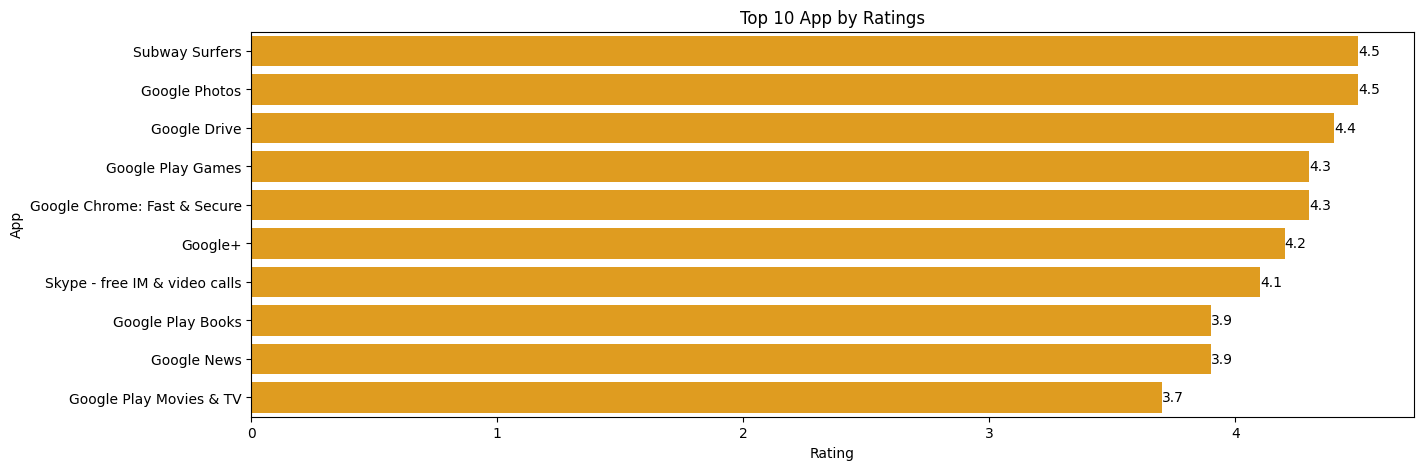

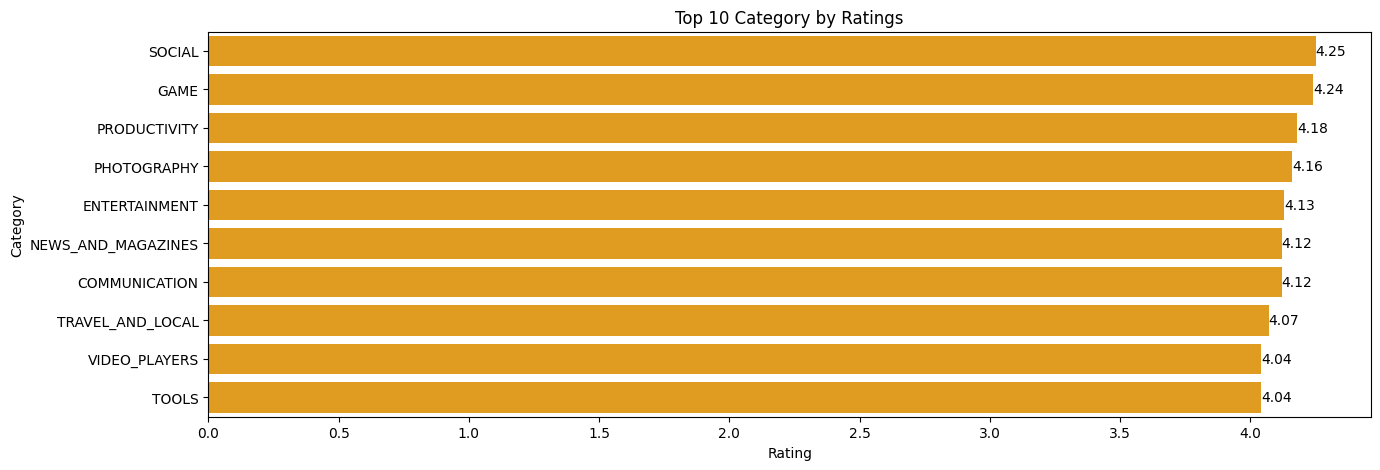

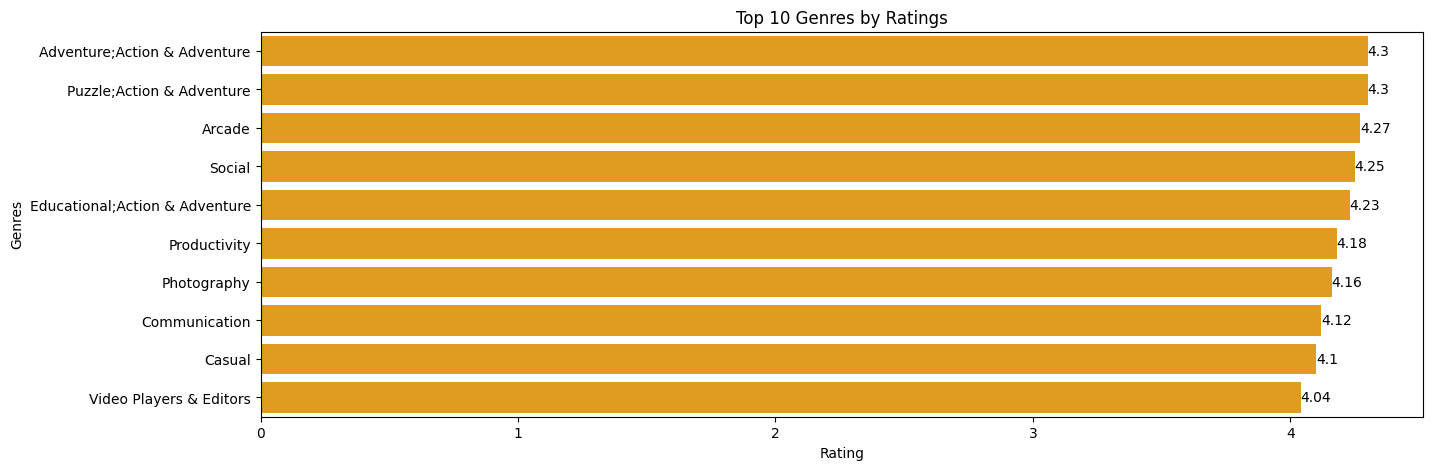

In [53]:
for i in ['App','Category','Genres']:
  appdf=df.groupby(i)[['Rating','Installs_In_Million']].mean().sort_values(by=['Installs_In_Million'],ascending=False).reset_index().head(10)
  appdf=round(appdf.sort_values(by=['Rating'],ascending=False),2)
  plt.figure(figsize=(15,5))
  plt.title(f'Top 10 {i} by Ratings')
  ax=sns.barplot(appdf,y=i,x='Rating',color='orange')
  ax.bar_label(ax.containers[0], fontsize=10);
  plt.ylabel(f'{i}')
  plt.xlabel('Rating')
  plt.show()

####Ralationship b/w **Installs** and **Price:**

<Axes: xlabel='Price', ylabel='Installs_In_Million'>

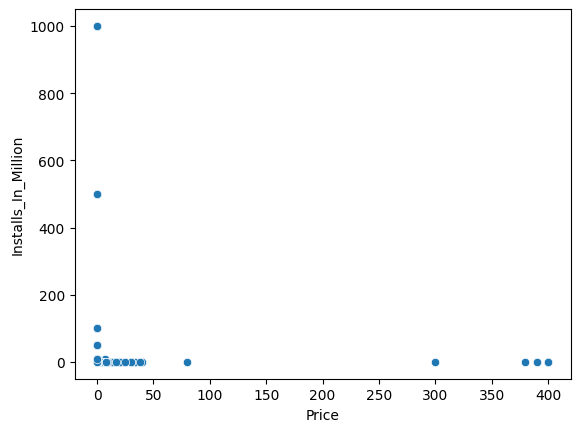

In [81]:
sns.scatterplot(data=df,x='Price',y='Installs_In_Million')

####Ralationship b/w **Installs** and **Reviews:**

<Axes: xlabel='Reviews', ylabel='Installs_In_Million'>

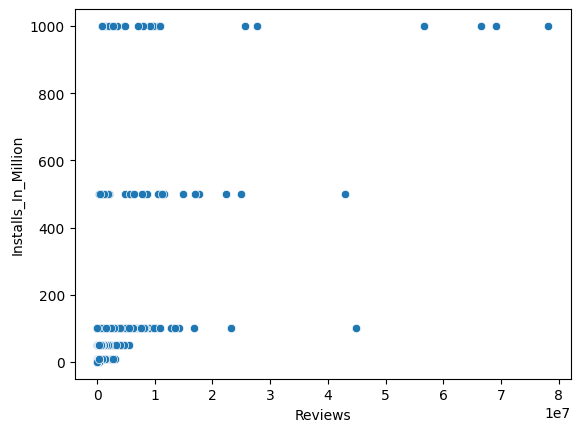

In [55]:
sns.scatterplot(data=df,x='Reviews',y='Installs_In_Million')

Relatinship between android version and raitng

costliet apps

In [56]:
df.sort_values(by='Price',ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs_In_Million,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver,Updated_year,Updated_month
3747,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3M,0.010,Paid,400.00,Everyone,Lifestyle,2018-05-03,1.0.1,4.1 and up,2018,May
4616,I AM RICH PRO PLUS,FINANCE,4.0,36,41M,0.001,Paid,399.99,Everyone,Finance,2018-06-25,1.0.2,4.1 and up,2018,June
4601,I am Rich!,FINANCE,3.8,93,22M,0.001,Paid,399.99,Everyone,Finance,2017-12-11,1,4.1 and up,2017,December
4605,I Am Rich Pro,FAMILY,4.4,201,2.7M,0.005,Paid,399.99,Everyone,Entertainment,2017-05-30,1.54,1.6 and up,2017,May
3742,💎 I'm rich,LIFESTYLE,3.8,718,26M,0.010,Paid,399.99,Everyone,Lifestyle,2018-03-11,1.0.0,4.4 and up,2018,March
4594,I am rich,LIFESTYLE,3.8,3547,1.8M,0.100,Paid,399.99,Everyone,Lifestyle,2018-01-12,2,4.0.3 and up,2018,January
4602,I am rich(premium),FINANCE,3.5,472,965k,0.005,Paid,399.99,Everyone,Finance,2017-05-01,3.4,4.4 and up,2017,May
4597,I am Rich Plus,FAMILY,4.0,856,8.7M,0.010,Paid,399.99,Everyone,Entertainment,2018-05-19,3,4.4 and up,2018,May
4612,I am Rich,FINANCE,4.3,180,3.8M,0.005,Paid,399.99,Everyone,Finance,2018-03-22,1,4.2 and up,2018,March
4607,I am rich (Most expensive app),FINANCE,4.1,129,2.7M,0.001,Paid,399.99,Teen,Finance,2017-12-06,2,4.0.3 and up,2017,December


###**Multivariate Analysis:**

####Top Apps in each category:

In [57]:
catdf=df.groupby('Category')['Installs_In_Million'].sum().reset_index().sort_values(by='Installs_In_Million',ascending=False).head().Category

In [58]:
list(catdf)

['GAME', 'COMMUNICATION', 'TOOLS', 'FAMILY', 'PRODUCTIVITY']

In [59]:
e=pd.DataFrame(columns=['App','Installs_In_Million','Rating','Category'])

In [60]:
for i in catdf:
  e1=df[df['Category']==i].groupby('App')[['Installs_In_Million','Rating']].mean().reset_index().sort_values(['Installs_In_Million','Rating'],ascending=[False,False]).head()
  e1['Category']=[i]*5
  u=pd.concat([e,e1],ignore_index=True)
  e=u.copy()

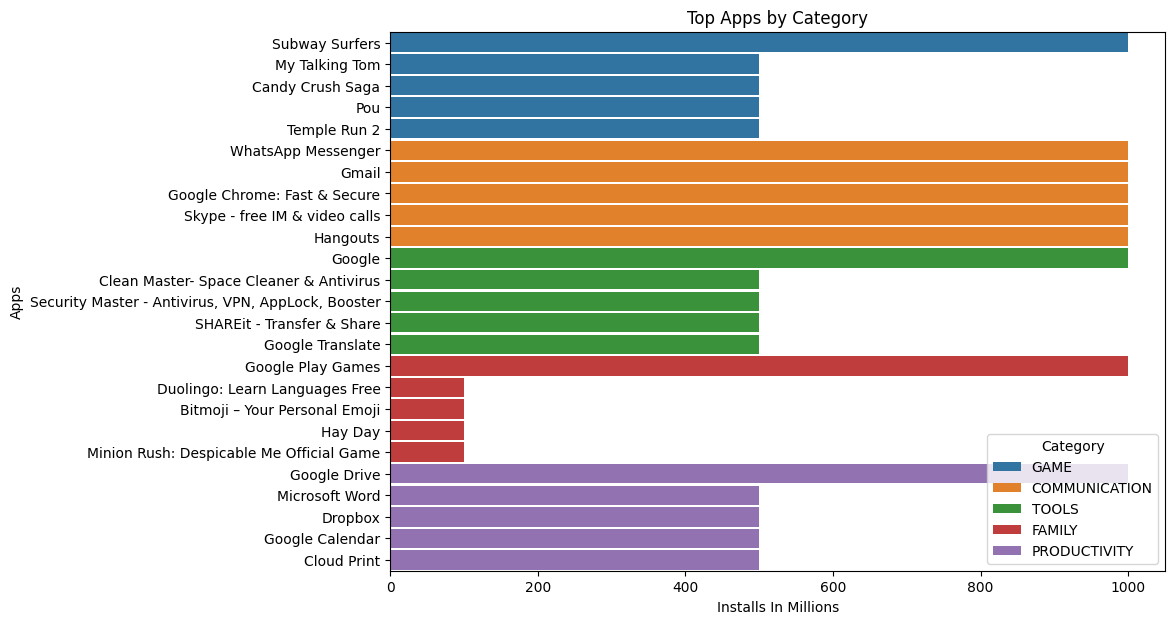

In [61]:
plt.figure(figsize=(10,7))
sns.barplot(data=u,x='Installs_In_Million',y='App',hue='Category',width=0.9)
plt.title('Top Apps by Category')
plt.xlabel('Installs In Millions')
plt.ylabel('Apps')
plt.show()

Top apps in free and paid category

In [62]:
freedf=df[df['Type']=='Free'].sort_values(by=['Installs_In_Million','Rating'],ascending=[False,False]).head(10)
paiddf=df[df['Type']=='Paid'].sort_values(by=['Installs_In_Million','Rating'],ascending=[False,False]).head(10)
z=pd.concat([freedf,paiddf],ignore_index=True)

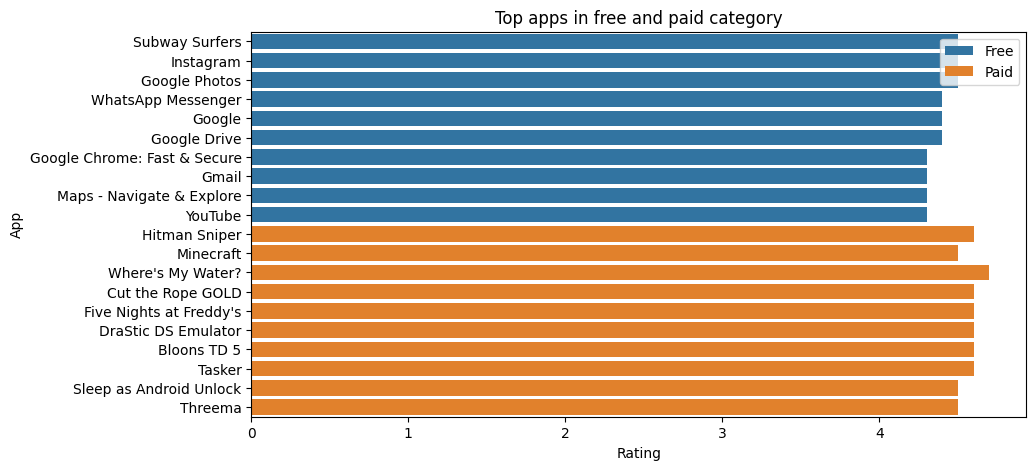

In [63]:
plt.figure(figsize=(10,5))
sns.barplot(data=z,x='Rating',y='App',hue='Type',legend=True)
plt.title('Top apps in free and paid category')
plt.legend(loc=1)
plt.show()

In [64]:
freedf=df[df['Type']=='Free'].groupby('Category')['Installs_In_Million'].sum()
paiddf=df[df['Type']=='Paid'].sort_values(by=['Installs_In_Million','Rating'],ascending=[False,False]).head(10)

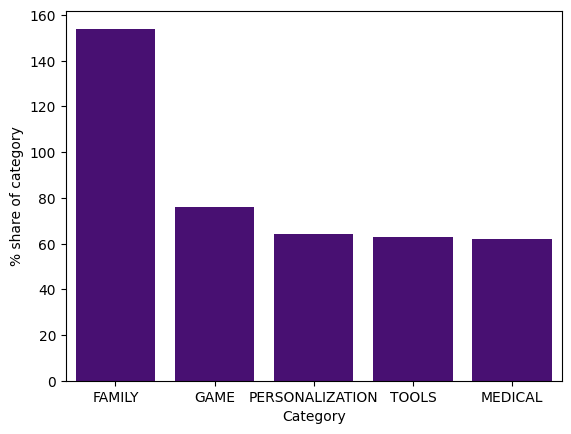

In [80]:
pdf=df[df['Type']=='Paid']['Category'].value_counts().reset_index().head(5)
dd['count']/=6
sns.barplot(data=pdf,x='Category',y='count',color='indigo')
plt.ylabel('% share of category')
plt.show()

In [79]:
pdf=df[df['Type']=='Paid']
pdf.groupby('Category')['Price'].agg(['min','max']).reset_index()

,Category,min,max
0,ART_AND_DESIGN,1.99,1.99
1,AUTO_AND_VEHICLES,1.99,1.99
2,BOOKS_AND_REFERENCE,0.99,4.60
3,BUSINESS,2.49,17.99
4,COMMUNICATION,0.99,4.99
5,DATING,3.99,7.99
6,EDUCATION,3.99,5.99
7,ENTERTAINMENT,2.99,4.99
8,FAMILY,0.99,399.99
9,FINANCE,1.99,399.99


In [ ]:
pdf=df[df['Type']=='Paid'].groupby(['Category'])['Price'].agg('min','max','mean')
dd['count']/=6
sns.barplot(data=dd,x='Category',y='count',color='indigo')
plt.ylabel('% share of category')
plt.show()

In [68]:
 df2=pd.read_csv('/content/User Reviews.csv')
df2.shape

FileNotFoundError: [Errno 2] No such file or directory: '/content/User Reviews.csv'

In [ ]:
df2[df2.duplicated()]

In [ ]:
df2

In [ ]:
df2.isnull().sum()

In [ ]:
df2['App'].nunique()

In [ ]:
df[df['App']=='10 Best Foods for You']

In [ ]:
df2[df2['App']=='10 Best Foods for You'].shape

In [ ]:
sns.scatterplot(data=df,x='Price',y='Installs_In_Million',hue='Type')

In [ ]:
df.hettad(3)

In [ ]:
df.groupby('Type')[['Installs_In_Million','Rating']].agg(['mean','median'])

In [ ]:
df.groupby('Type')[['Installs_In_Million','Rating']].agg({'Installs_In_Million':'sum','Rating':['mean','median']})

In [ ]:
df.groupby('Content Rating')[['Installs_In_Million']].sum().reset_index().sort_values(by='Installs_In_Million',ascending=False)

In [ ]:
df.groupby(['App','Type'])[['Reviews','Installs_In_Million','Rating']].max().sort_values(by='Installs_In_Million',ascending=False).reset_index().head(10)

In [ ]:
df.groupby(['Category','Type'])[['Installs_In_Million']].sum().sort_values(by='Installs_In_Million',ascending=False).reset_index().head(10)

In [ ]:
df[(df["Type"]=='Paid') & (df['Category']=='COMMUNICATION')]

In [ ]:
c=df.groupby(['Category','Type'])[['Rating']].mean().sort_values(by='Rating',ascending=False).reset_index()
c.head(20)

In [ ]:
df.corr()